<a href="https://colab.research.google.com/github/Ravi-Teja2111/Shor-s-Algorithm/blob/main/QFT/QFTandIQFT_4qubits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit pylatexenc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=d44fbe2df3d09f079c9db280041b33c281cd5ad2846f6ac8cce58b63d87ed883
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


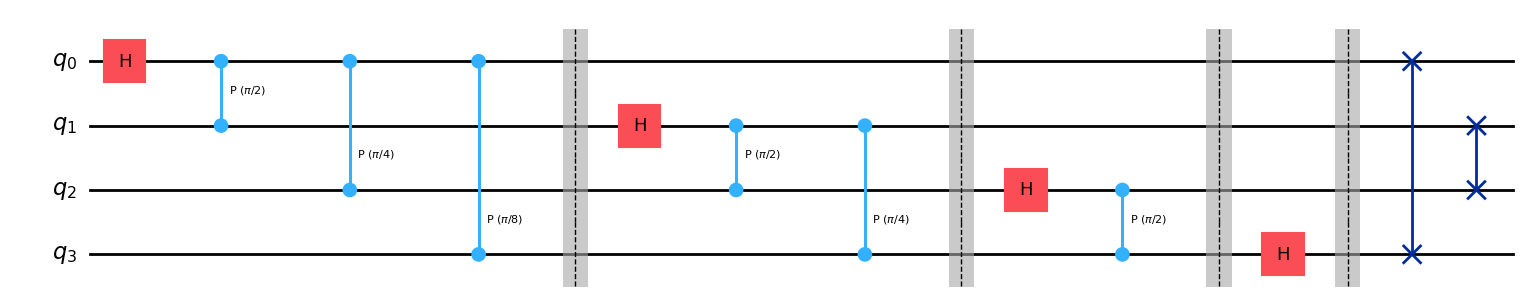

In [9]:
import numpy as np
from qiskit import QuantumCircuit

def qft_4():
    qc = QuantumCircuit(4)

    qc.h(0)
    qc.cp(np.pi/2, 1, 0)
    qc.cp(np.pi/4, 2, 0)
    qc.cp(np.pi/8, 3, 0)
    qc.barrier()

    qc.h(1)
    qc.cp(np.pi/2, 2, 1)
    qc.cp(np.pi/4, 3, 1)
    qc.barrier()

    qc.h(2)
    qc.cp(np.pi/2, 3, 2)
    qc.barrier()

    qc.h(3)
    qc.barrier()

    qc.swap(0, 3)
    qc.swap(1, 2)

    return qc


def iqft_4():
    qc = QuantumCircuit(4)

    # SWAP first
    qc.swap(0, 3)
    qc.swap(1, 2)
    qc.barrier()

    # Inverse block 1 (mirrors QFT block 4 — h(3))
    qc.h(3)
    qc.barrier()

    # Inverse block 2 (mirrors QFT block 3)
    qc.cp(-np.pi/2, 3, 2)
    qc.h(2)
    qc.barrier()

    # Inverse block 3 (mirrors QFT block 2)
    qc.cp(-np.pi/4, 3, 1)
    qc.cp(-np.pi/2, 2, 1)
    qc.h(1)
    qc.barrier()

    # Inverse block 4 (mirrors QFT block 1)
    qc.cp(-np.pi/8, 3, 0)
    qc.cp(-np.pi/4, 2, 0)
    qc.cp(-np.pi/2, 1, 0)
    qc.h(0)

    return qc


# Draw them SEPARATELY
qft_4().draw('mpl')

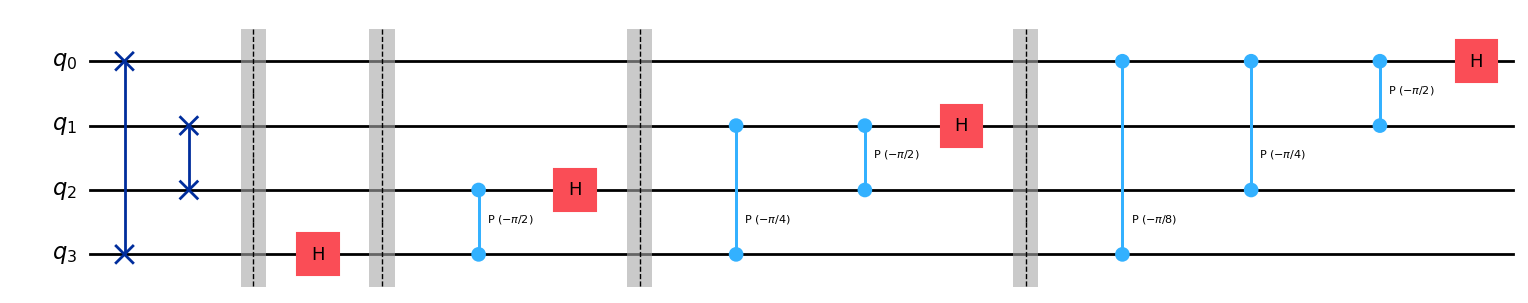

In [10]:
iqft_4().draw('mpl')

In [12]:
# Compose them together to verify roundtrip
from qiskit.quantum_info import Statevector

full = QuantumCircuit(4)
full.x(3)                          # start with |0001⟩
full.compose(qft_4(), inplace=True)
full.compose(iqft_4(), inplace=True)

sv = Statevector(full)
sv.draw('latex')                   # should show |0001⟩ back

<IPython.core.display.Latex object>

In [16]:
!pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.3 MB/s eta 0:00:00


Measurement results: {'0000': 1024}


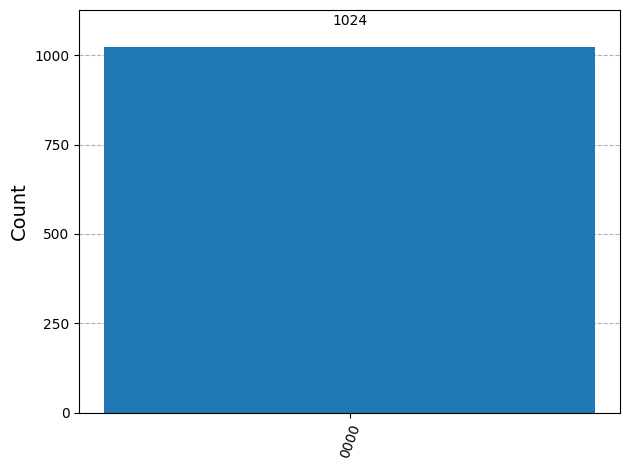

In [19]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

def full_circuit():
    qc = QuantumCircuit(4)

                                # initial state |0001⟩
    qc.compose(qft_4(), inplace=True)   # apply QFT
    qc.barrier()
    qc.compose(iqft_4(), inplace=True)  # apply IQFT
    qc.measure_all()
    return qc

# Run on simulator
simulator = Aer.get_backend('aer_simulator')
qc = full_circuit()
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1024).result()
counts = result.get_counts()

print("Measurement results:", counts)
plot_histogram(counts)